<a href="https://colab.research.google.com/github/vivekkuamar-dudhat/Artificial_intelligence/blob/main/artificial_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam, SGD

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


In [4]:
def build_fcn_model(activation_function, optimizer_type="adam"):

    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))

    model.add(Dense(256, activation=activation_function))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation=activation_function))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation=activation_function))

    model.add(Dense(64, activation=activation_function))
    model.add(Dense(64, activation=activation_function))

    model.add(Dense(32, activation=activation_function))

    model.add(Dense(10, activation="softmax"))

    if optimizer_type == "adam":
        optimizer = Adam(0.001)
    else:
        optimizer = SGD(learning_rate=0.01, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [6]:

def build_cnn_model():

    model = Sequential()

    model.add(Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64,(3,3),activation="relu"))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())

    model.add(Dense(128,activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(10,activation="softmax"))

    model.compile(
        optimizer=Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [7]:
def train_model(model, name):

    print(f"\nTraining {name} Model...\n")

    history = model.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    return history

In [8]:
def evaluate_model(model, name):

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"\n{name} Performance:")
    print("Loss:", loss)
    print("Accuracy:", acc)

    return loss, acc


In [9]:
def plot_results(history, name):

    plt.figure()
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title(name+" Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Validation"])
    plt.show()

    plt.figure()
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title(name+" Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train","Validation"])
    plt.show()

In [10]:
def show_misclassified(model, x, y):

    pred = model.predict(x)
    labels = np.argmax(pred, axis=1)

    wrong = np.where(labels != y)[0]

    plt.figure(figsize=(10,4))

    for i, idx in enumerate(wrong[:10]):
        plt.subplot(2,5,i+1)
        plt.imshow(x[idx].reshape(28,28), cmap="gray")
        plt.title(f"T:{y[idx]} P:{labels[idx]}")
        plt.axis("off")

    plt.show()


Training Sigmoid-Adam Model...

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2224 - loss: 2.1161 - val_accuracy: 0.6012 - val_loss: 1.1780
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6257 - loss: 1.0820 - val_accuracy: 0.7759 - val_loss: 0.7352
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7779 - loss: 0.7187 - val_accuracy: 0.8955 - val_loss: 0.4698
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8838 - loss: 0.4707 - val_accuracy: 0.9293 - val_loss: 0.3085
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9164 - loss: 0.3371 - val_accuracy: 0.9448 - val_loss: 0.2432
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9306 - loss: 0.2725 - val_accuracy: 0.9493 - val_loss: 0.2123
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9405 - loss: 0.2310 - val_accuracy: 0.9549 - val_loss: 0.1841
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.

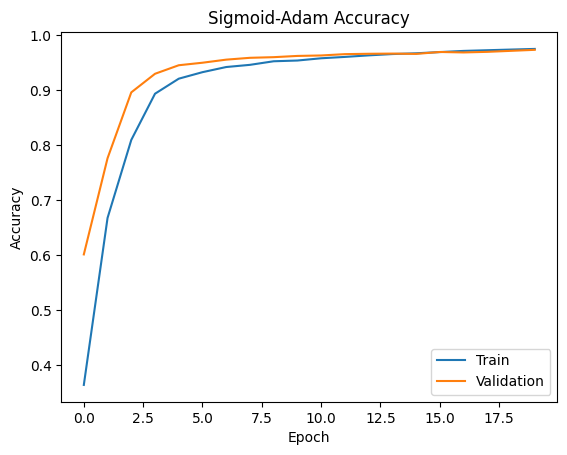

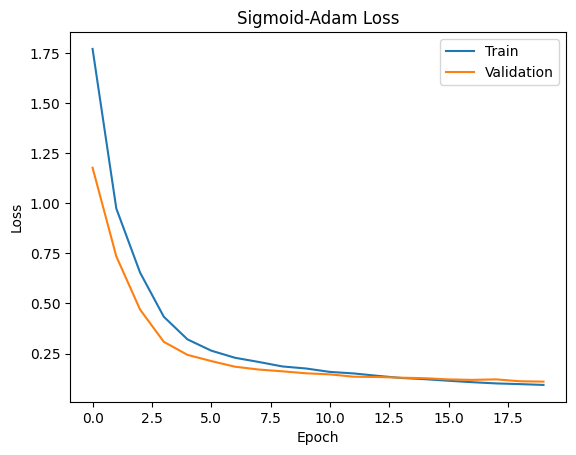


Training Tanh-Adam Model...

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7861 - loss: 0.7533 - val_accuracy: 0.9354 - val_loss: 0.2311
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9228 - loss: 0.2627 - val_accuracy: 0.9469 - val_loss: 0.1785
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9414 - loss: 0.2006 - val_accuracy: 0.9570 - val_loss: 0.1412
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9486 - loss: 0.1737 - val_accuracy: 0.9615 - val_loss: 0.1379
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9530 - loss: 0.1549 - val_accuracy: 0.9617 - val_loss: 0.1325
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9562 - loss: 0.1458 - val_accuracy: 0.9660 - val_loss: 0.1195
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9598 - loss: 0.1298 - val_accuracy: 0.9688 - val_loss: 0.1157
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.

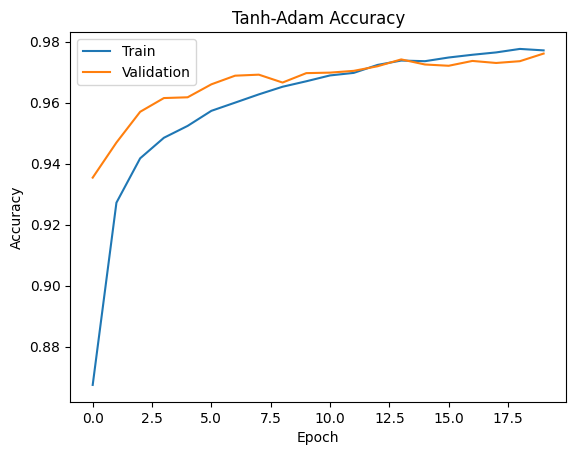

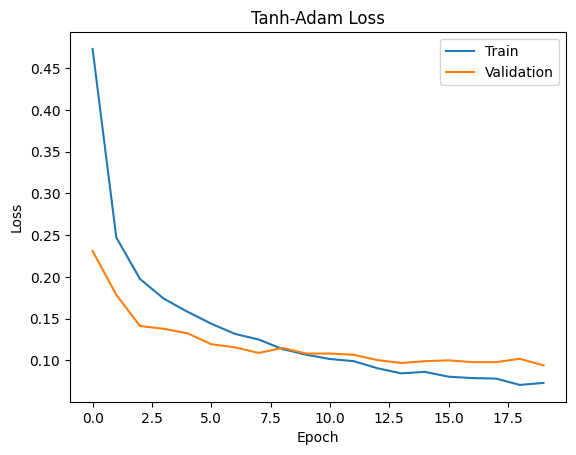


Training Tanh-SGD Model...

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7038 - loss: 0.9897 - val_accuracy: 0.9165 - val_loss: 0.2855
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9008 - loss: 0.3402 - val_accuracy: 0.9297 - val_loss: 0.2357
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9168 - loss: 0.2760 - val_accuracy: 0.9427 - val_loss: 0.1970
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9284 - loss: 0.2368 - val_accuracy: 0.9487 - val_loss: 0.1774
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9341 - loss: 0.2157 - val_accuracy: 0.9516 - val_loss: 0.1617
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9385 - loss: 0.1979 - val_accuracy: 0.9549 - val_loss: 0.1548
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9437 - loss: 0.1844 - val_accuracy: 0.9593 - val_loss: 0.1402
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9484 - 

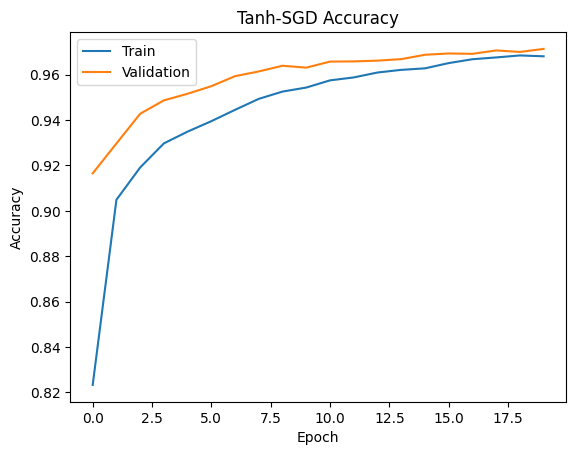

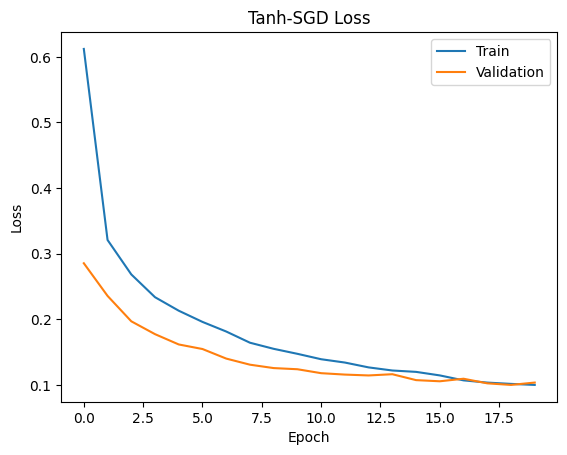

In [12]:
results = []


sigmoid_adam = build_fcn_model("sigmoid","adam")
sigmoid_hist = train_model(sigmoid_adam,"Sigmoid-Adam")
sig_loss, sig_acc = evaluate_model(sigmoid_adam,"Sigmoid-Adam")
plot_results(sigmoid_hist,"Sigmoid-Adam")
results.append(["FCN","Sigmoid","Adam","Yes",sig_acc,sig_loss])


tanh_adam = build_fcn_model("tanh","adam")
tanh_hist = train_model(tanh_adam,"Tanh-Adam")
tanh_loss, tanh_acc = evaluate_model(tanh_adam,"Tanh-Adam")
plot_results(tanh_hist,"Tanh-Adam")
results.append(["FCN","Tanh","Adam","Yes",tanh_acc,tanh_loss])


tanh_sgd = build_fcn_model("tanh","sgd")
tanh_sgd_hist = train_model(tanh_sgd,"Tanh-SGD")
sgd_loss, sgd_acc = evaluate_model(tanh_sgd,"Tanh-SGD")
plot_results(tanh_sgd_hist,"Tanh-SGD")
results.append(["FCN","Tanh","SGD","Yes",sgd_acc,sgd_loss])

In [15]:
cnn_model = build_cnn_model()

print("\nCNN MODEL SUMMARY")
cnn_model.summary()

cnn_hist = cnn_model.fit(
    x_train_cnn,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn,y_test,verbose=0)

print("\nCNN Performance:")
print("Loss:",cnn_loss)
print("Accuracy:",cnn_acc)

results.append(["CNN","ReLU","Adam","Yes",cnn_acc,cnn_loss])



CNN MODEL SUMMARY


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.8119 - loss: 0.6175 - val_accuracy: 0.9803 - val_loss: 0.0702
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 92ms/step - accuracy: 0.9757 - loss: 0.0840 - val_accuracy: 0.9846 - val_loss: 0.0522
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.9828 - loss: 0.0570 - val_accuracy: 0.9873 - val_loss: 0.0447
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9868 - loss: 0.0439 - val_accuracy: 0.9879 - val_loss: 0.0419
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 89ms/step - accuracy: 0.9903 - loss: 0.0321 - val_accuracy: 0.9891 - val_loss: 0.0386
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9905 - loss: 0.0310 - val_accuracy: 0.9904 - val_loss: 0.0336
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.9916 - loss: 0.0244 - val_accuracy: 0.9906 - val_loss: 0.0345
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - accuracy: 0.9929 - loss: 0.0208 -


Misclassified (Best FCN - Tanh Adam)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


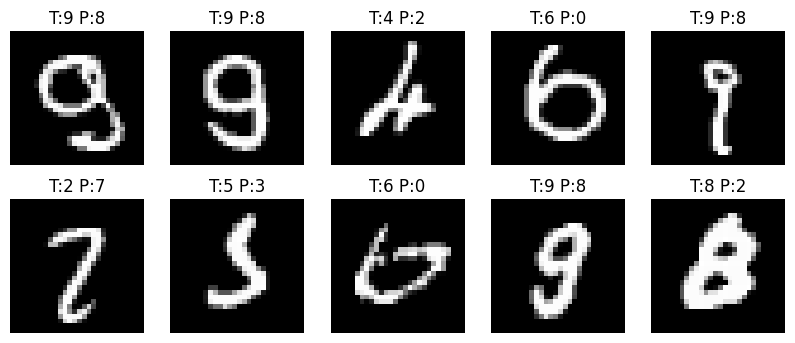


Misclassified (CNN)
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


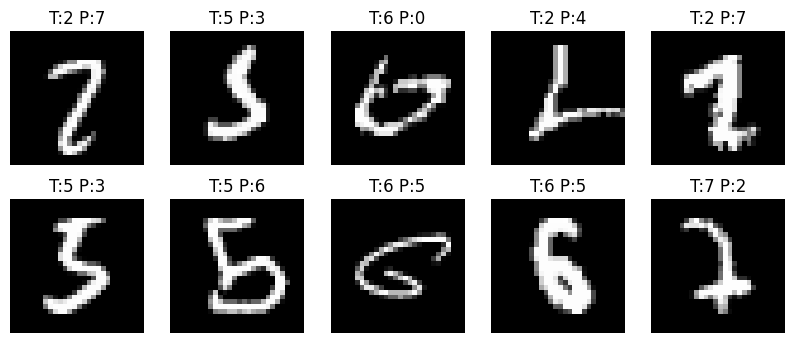

In [16]:
print("\nMisclassified (Best FCN - Tanh Adam)")
show_misclassified(tanh_adam,x_test,y_test)

print("\nMisclassified (CNN)")
show_misclassified(cnn_model,x_test_cnn,y_test)

In [17]:
print("\n================ SUMMARY TABLE ================\n")

print("Model | Activation | Optimizer | Dropout | Accuracy | Loss")
print("------------------------------------------------------------")

for r in results:
    print(f"{r[0]} | {r[1]} | {r[2]} | {r[3]} | {r[4]:.4f} | {r[5]:.4f}")

print("\n==============================================\n")


================ SUMMARY TABLE ================

Model | Activation | Optimizer | Dropout | Accuracy | Loss
------------------------------------------------------------
FCN | Sigmoid | Adam | Yes | 0.9718 | 0.1078
FCN | Tanh | Adam | Yes | 0.9753 | 0.0952
FCN | Tanh | SGD | Yes | 0.9700 | 0.1023
CNN | ReLU | Adam | Yes | 0.9923 | 0.0332




In [18]:
sigmoid_adam.save("sigmoid_fcn.keras")
tanh_adam.save("tanh_fcn.keras")
tanh_sgd.save("tanh_sgd_fcn.keras")
cnn_model.save("cnn_model.keras")

print("All models saved successfully.")

All models saved successfully.
